In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("patients.csv")

In [3]:
df.head()

,Id,BIRTHDATE,DEATHDATE,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON
0,5605b66b-e92d-c16c-1b83-b8bf7040d51f,1977-03-19,NaN,Mrs.,Nikita578,Erdman779,NaN,Leannon79,M,white,nonhispanic,F,Wakefield Massachusetts US,510 Little Station Unit 69,Quincy,Massachusetts,Norfolk County,2186.0,42.290937,-70.975503
1,6e5ae27c-8038-7988-e2c0-25a103f01bfa,1940-02-19,NaN,Mr.,Zane918,Hodkiewicz467,NaN,NaN,M,white,nonhispanic,M,Brookline Massachusetts US,747 Conn Throughway,Boston,Massachusetts,Suffolk County,2135.0,42.308831,-71.063162
2,8123d076-0886-9007-e956-d5864aa121a7,1958-06-04,NaN,Mr.,Quinn173,Marquardt819,NaN,NaN,M,white,nonhispanic,M,Gardner Massachusetts US,816 Okuneva Extension Apt 91,Quincy,Massachusetts,Norfolk County,2170.0,42.265177,-70.967085
3,770518e4-6133-648e-60c9-071eb2f0e2ce,1928-12-25,2017-09-29,Mr.,Abel832,Smitham825,NaN,NaN,M,white,hispanic,M,Randolph Massachusetts US,127 Cole Way Unit 95,Boston,Massachusetts,Suffolk County,2118.0,42.334304,-71.066801
4,f96addf5-81b9-0aab-7855-d208d3d352c5,1928-12-25,2014-02-23,Mr.,Edwin773,Labadie908,NaN,NaN,M,white,hispanic,M,Stow Massachusetts US,976 Ziemann Gateway,Boston,Massachusetts,Suffolk County,2125.0,42.346771,-71.058813


In [4]:
df.columns

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX',
       'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE',
       'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 974 entries, 0 to 973
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          974 non-null    object 
 1   BIRTHDATE   974 non-null    object 
 2   DEATHDATE   154 non-null    object 
 3   PREFIX      974 non-null    object 
 4   FIRST       974 non-null    object 
 5   LAST        974 non-null    object 
 6   SUFFIX      21 non-null     object 
 7   MAIDEN      386 non-null    object 
 8   MARITAL     973 non-null    object 
 9   RACE        974 non-null    object 
 10  ETHNICITY   974 non-null    object 
 11  GENDER      974 non-null    object 
 12  BIRTHPLACE  974 non-null    object 
 13  ADDRESS     974 non-null    object 
 14  CITY        974 non-null    object 
 15  STATE       974 non-null    object 
 16  COUNTY      974 non-null    object 
 17  ZIP         832 non-null    float64
 18  LAT         974 non-null    float64
 19  LON         974 non-null    f

In [6]:
df.shape

(974, 20)

In [7]:
df.describe()

,ZIP,LAT,LON
count,832.000000,974.000000,974.000000
mean,2152.421875,42.337359,-71.027524
std,75.462146,0.047594,0.069375
min,1801.000000,42.204921,-71.165648
25%,2121.000000,42.313366,-71.068002
50%,2135.000000,42.343794,-71.038397
75%,2163.000000,42.371594,-70.999202
max,2472.000000,42.495464,-70.730824


In [8]:
df.isnull().sum()

Id              0
BIRTHDATE       0
DEATHDATE     820
PREFIX          0
FIRST           0
LAST            0
SUFFIX        953
MAIDEN        588
MARITAL         1
RACE            0
ETHNICITY       0
GENDER          0
BIRTHPLACE      0
ADDRESS         0
CITY            0
STATE           0
COUNTY          0
ZIP           142
LAT             0
LON             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Id'].duplicated().sum()

np.int64(0)

### Python - Convert Date Columns

In [11]:
df['BIRTHDATE'] = pd.to_datetime(df['BIRTHDATE'])
df['DEATHDATE'] = pd.to_datetime(df['DEATHDATE'])

### Unique Values in Categorical Columns

In [12]:
categorical_columns = ['MARITAL', 'RACE', 'ETHNICITY', 'GENDER']

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


MARITAL:
['M' 'S' nan]

RACE:
['white' 'asian' 'black' 'native' 'hawaiian' 'other']

ETHNICITY:
['nonhispanic' 'hispanic']

GENDER:
['F' 'M']


### Categorical Value Counts

In [13]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


MARITAL:
MARITAL
M    784
S    189
Name: count, dtype: int64

RACE:
RACE
white       680
black       163
asian        91
other        16
hawaiian     13
native       11
Name: count, dtype: int64

ETHNICITY:
ETHNICITY
nonhispanic    783
hispanic       191
Name: count, dtype: int64

GENDER:
GENDER
M    494
F    480
Name: count, dtype: int64


In [14]:
df[['ZIP', 'LAT', 'LON']].describe()

,ZIP,LAT,LON
count,832.000000,974.000000,974.000000
mean,2152.421875,42.337359,-71.027524
std,75.462146,0.047594,0.069375
min,1801.000000,42.204921,-71.165648
25%,2121.000000,42.313366,-71.068002
50%,2135.000000,42.343794,-71.038397
75%,2163.000000,42.371594,-70.999202
max,2472.000000,42.495464,-70.730824


In [15]:
print("Gender:",df['GENDER'].unique())
print("Race:", df['RACE'].unique())
print("Ethnicity", df['ETHNICITY'].unique())
print("Marital", df['MARITAL'].unique())

Gender: ['F' 'M']
Race: ['white' 'asian' 'black' 'native' 'hawaiian' 'other']
Ethnicity ['nonhispanic' 'hispanic']
Marital ['M' 'S' nan]


### Calculate Patient Age

In [16]:
df["Age"] = (
    pd.Timestamp.today().normalize() - df['BIRTHDATE']
).dt.days // 365

In [17]:
df[['BIRTHDATE', 'Age']].head()

,BIRTHDATE,Age
0,1977-03-19,49
1,1940-02-19,86
2,1958-06-04,68
3,1928-12-25,97
4,1928-12-25,97


### Age Distribution Summary

In [18]:
df['Age'].describe()

count    974.000000
mean      73.993840
std       20.498664
min       34.000000
25%       56.000000
50%       76.000000
75%       93.000000
max      104.000000
Name: Age, dtype: float64

### Create Age Groups

In [19]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[33, 40, 60, 80, 100, 110],
    labels = ['34-40', '41-60', '61-80', '81-100', '101+']
)

In [20]:
df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,49,41-60
1,86,81-100
2,68,61-80
3,97,81-100
4,97,81-100


### Patient Count by Age Group

In [21]:
df['Age_Group'].value_counts().sort_index()

Age_Group
34-40      59
41-60     235
61-80     247
81-100    364
101+       69
Name: count, dtype: int64

### Age Group Distribution

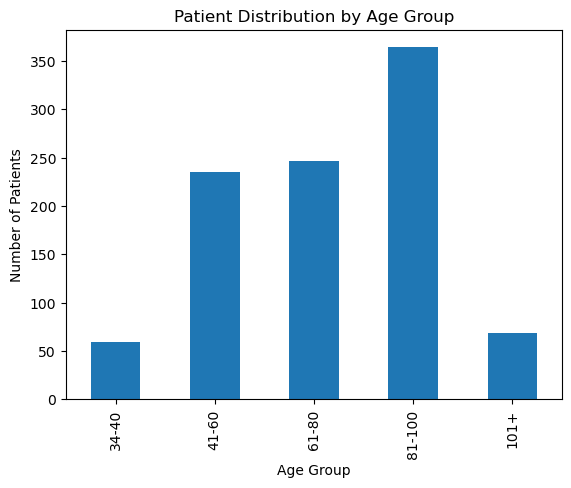

In [22]:
df['Age_Group'].value_counts().sort_index().plot(kind = 'bar')

plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 90)
plt.show()

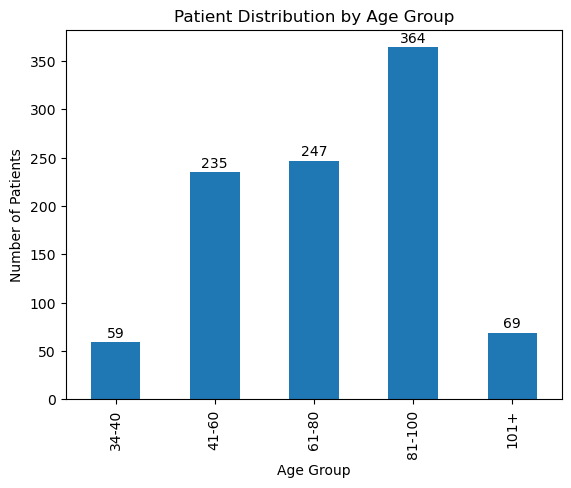

In [23]:
age_counts = df['Age_Group'].value_counts().sort_index()

ax = age_counts.plot(kind = 'bar')

plt.title('Patient Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation = 90)

for i, value in enumerate(age_counts):
    ax.text(i, value + 5, str(value), ha = 'center')

plt.show()

### GENDER DISTRIBUTION

In [24]:
gender_counts = df['GENDER'].value_counts()

gender_percentage = (gender_counts / len(df)) * 100

print(gender_percentage.round(2))

GENDER
M    50.72
F    49.28
Name: count, dtype: float64


### Gender Distribution Piechart

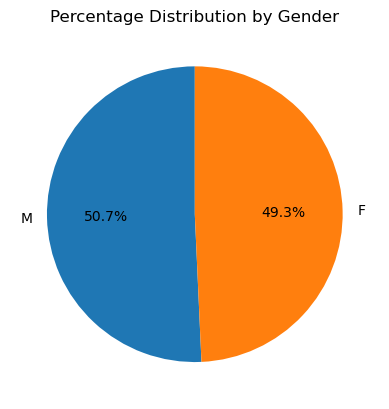

In [25]:
gender_counts = df['GENDER'].value_counts()

plt.pie(
    gender_counts,
    labels = gender_counts.index,
    autopct = '%1.1f%%',
    startangle = 90
)

plt.title('Percentage Distribution by Gender')

plt.show()

### RACE DISTRIBUTION

In [26]:
race_counts = df['RACE'].value_counts()

print(race_counts)

RACE
white       680
black       163
asian        91
other        16
hawaiian     13
native       11
Name: count, dtype: int64


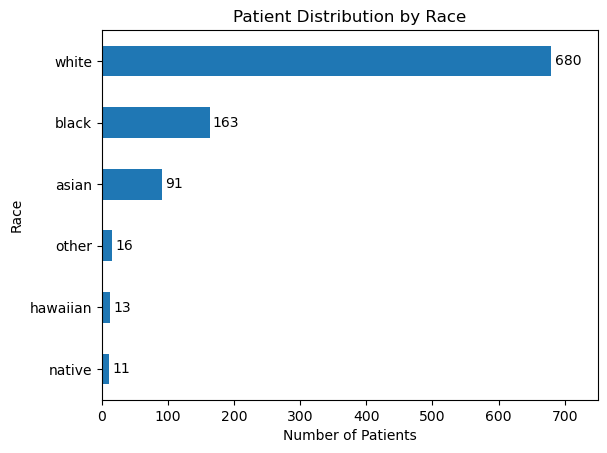

In [27]:
race_counts = df['RACE'].value_counts().sort_values()

ax = race_counts.plot(kind = 'barh')

plt.title('Patient Distribution by Race')
plt.xlabel('Number of Patients')
plt.ylabel('Race')
plt.xlim(0,750)

for i, value in enumerate(race_counts):
    ax.text(value + 5, i, str(value), va = 'center')
plt.show()

### ETHNICITY DISTRIBUTION

In [28]:
ethnicity_counts = df['ETHNICITY'].value_counts()

ethnicity_percentage = (ethnicity_counts / len(df) * 100)

print(ethnicity_percentage.round(2))

ETHNICITY
nonhispanic    80.39
hispanic       19.61
Name: count, dtype: float64


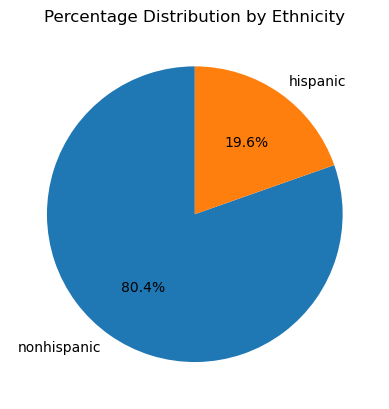

In [29]:
ethnicity_counts = df['ETHNICITY'].value_counts()

plt.pie(
    ethnicity_counts,
    labels = ethnicity_counts.index,
    autopct = '%1.1f%%',
    startangle = 90
)

plt.title('Percentage Distribution by Ethnicity')
plt.show()

### MARITAL STATUS DISTRIBUTION

In [30]:
marital_status = df['MARITAL'].value_counts(dropna = False)

print(marital_status)

MARITAL
M      784
S      189
NaN      1
Name: count, dtype: int64


In [31]:
marital_counts = df['MARITAL'].value_counts()

marital_percentage = (marital_counts / len(df)) * 100

print(marital_percentage.round(2))

MARITAL
M    80.49
S    19.40
Name: count, dtype: float64


### Patient Status Distribution

In [32]:
status_counts = df['DEATHDATE'].isna().map({
    True: 'Alive',
    False: 'Deceased'
}).value_counts()

status_percentage = (status_counts / len(df)) * 100

print(status_counts)
print()
print(status_percentage.round(2))

DEATHDATE
Alive       820
Deceased    154
Name: count, dtype: int64

DEATHDATE
Alive       84.19
Deceased    15.81
Name: count, dtype: float64


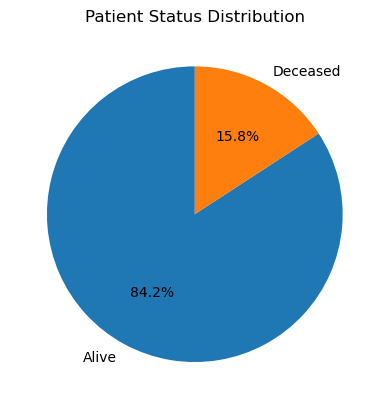

In [33]:
plt.pie(
    status_counts,
    labels = status_counts.index,
    autopct = '%1.1f%%',
    startangle = 90
)

plt.title('Patient Status Distribution')
plt.show()

In [34]:
average_age_by_status = df.groupby(
    df['DEATHDATE'].isna().map({
        True : 'Alive',
        False : 'Deceased'
    })
)['Age'].mean().round(2)

print(average_age_by_status)

DEATHDATE
Alive       71.17
Deceased    89.05
Name: Age, dtype: float64


### Deceased Patients by Age Group

In [35]:
deceased_age_group = df[df['DEATHDATE'].notna()]['Age_Group'].value_counts().sort_values()

print(deceased_age_group)

Age_Group
34-40       1
41-60      10
101+       17
61-80      20
81-100    106
Name: count, dtype: int64


### Death Rate by Age Group

In [36]:
death_date_by_age = (
    df.groupby('Age_Group', observed = True)['DEATHDATE']
      .apply(lambda x: x.notna().mean() * 100)
      .round(2)
)

print(death_date_by_age)

Age_Group
34-40      1.69
41-60      4.26
61-80      8.10
81-100    29.12
101+      24.64
Name: DEATHDATE, dtype: float64


### Death Rate by Age Group Chart

<function matplotlib.pyplot.show(close=None, block=None)>

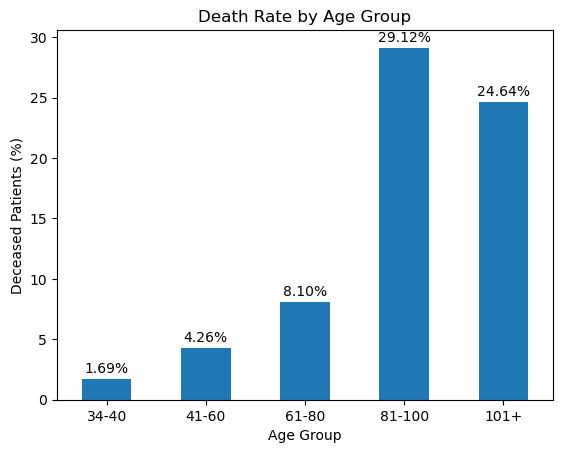

In [37]:
ax = death_date_by_age.plot(kind = 'bar')

plt.title('Death Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Deceased Patients (%)')
plt.xticks(rotation = 0)

for i, value in enumerate(death_date_by_age):
    ax.text(i, value + 0.5, f'{value:.2f}%', ha = 'center')

plt.show

### DEATH RATE BY GENDER

In [38]:
gender_death_rate = (
    df.groupby('GENDER')['DEATHDATE']
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

print(gender_death_rate)

GENDER
F    13.96
M    17.61
Name: DEATHDATE, dtype: float64


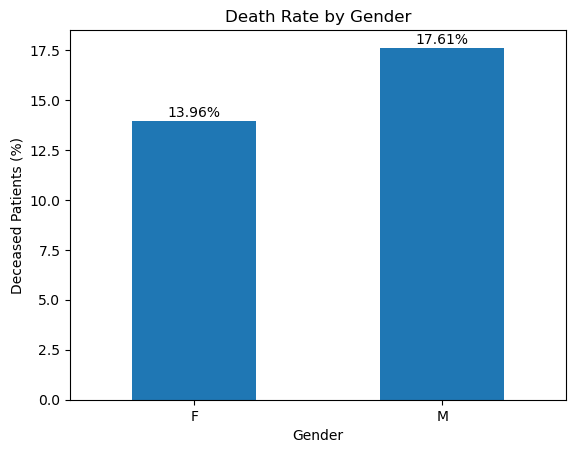

In [39]:
ax = gender_death_rate.plot(kind = 'bar')

plt.title('Death Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Deceased Patients (%)')
plt.xticks(rotation = 0)

for i, value in enumerate(gender_death_rate):
    ax.text(i, value + 0.2, f'{value:.2f}%', ha = 'center')

plt.show()

### DEATH RATE BY RACE

In [40]:
race_death_rate = (
    df.groupby('RACE')['DEATHDATE']
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

print(race_death_rate)

RACE
asian       14.29
black       18.40
hawaiian     0.00
native      27.27
other       31.25
white       15.15
Name: DEATHDATE, dtype: float64


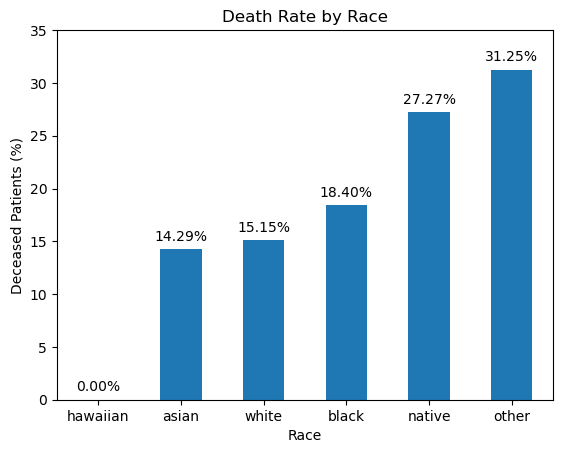

In [41]:
race_death_rate_sorted = race_death_rate.sort_values()

ax = race_death_rate_sorted.plot(kind = 'bar')

plt.title('Death Rate by Race')
plt.xlabel('Race')
plt.ylabel('Deceased Patients (%)')
plt.xticks(rotation = 0)

for i, value in enumerate(race_death_rate_sorted):
    ax.text(i, value + 0.8, f'{value:.2f}%', ha = 'center')

plt.ylim(0, 35)

plt.show()

### Death Rate by Ethnicity

In [42]:
ethnicity_death_rate = (
    df.groupby('ETHNICITY')['DEATHDATE']
    .apply(lambda x: x.notna().mean() * 100)
    .round(2)
)

print(ethnicity_death_rate)

ETHNICITY
hispanic       17.28
nonhispanic    15.45
Name: DEATHDATE, dtype: float64


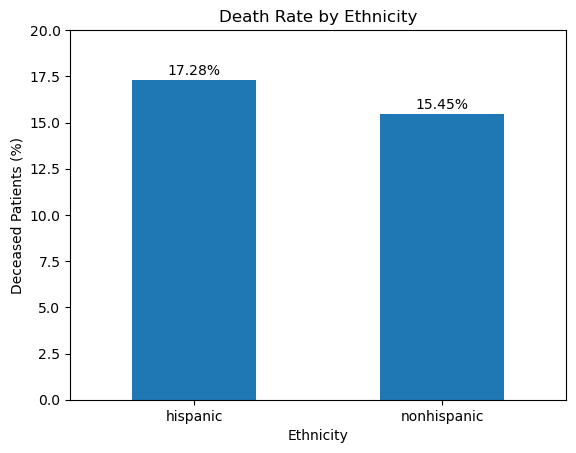

In [43]:
ax = ethnicity_death_rate.plot(kind = 'bar')

plt.title('Death Rate by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Deceased Patients (%)')
plt.xticks(rotation = 0)

for i, value in enumerate(ethnicity_death_rate):
    ax.text(i, value + 0.3, f'{value:.2f}%', ha = 'center')

plt.ylim(0, 20)

plt.show()

### Number of Encounters per Patient

In [44]:
encounters = pd.read_csv("encounters.csv")

In [45]:
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,1018.02,0.00,NaN,NaN
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,2619.36,0.00,NaN,NaN
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03T14:32:11Z,2011-01-03T14:47:11Z,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03T16:24:45Z,2011-01-03T16:39:45Z,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,1784.24,0.00,NaN,NaN
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03T17:36:53Z,2011-01-03T17:51:53Z,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,55822004.0,Hyperlipidemia


In [46]:
encounter_count = (
    encounters.groupby('PATIENT')
    .size()
    .sort_values(ascending = False)
)

print(encounter_count.head(10))

PATIENT
1712d26d-822d-1e3a-2267-0a9dba31d7c8    1381
5e055638-0dad-dfd5-005d-1e74b6fd29ac     887
3de74169-7f67-9304-91d4-757e0f3a14d2     877
3f523789-55f3-bb31-2757-4803ca6a9c2a     447
5dcb295d-92df-a147-ebcc-aa49b6262830     441
442dc617-c7f2-0513-15cd-c35c4efdba73     392
b4ab9ab3-f52a-751e-a990-3bd5654d5870     383
9b8ae606-5059-b3a6-19c7-c812901898bb     364
b4671e80-7e87-9260-ca31-6a9397d465d1     296
ff331e5c-ab16-e218-f39a-63e11de1ed75     291
dtype: int64


In [47]:
encounter_count.describe()

count     974.000000
mean       28.635524
std        73.035671
min         1.000000
25%         4.000000
50%        14.000000
75%        28.000000
max      1381.000000
dtype: float64

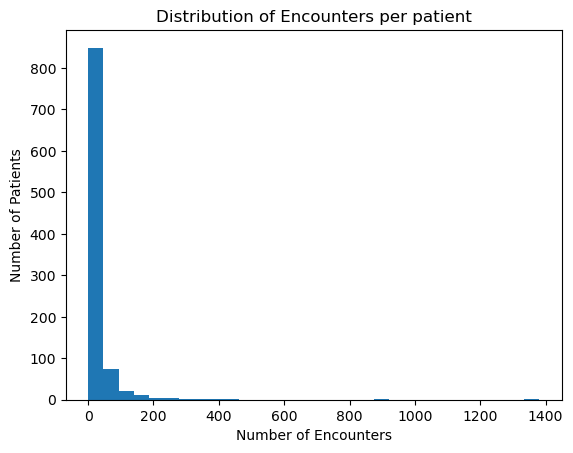

In [48]:
plt.hist(encounter_count, bins = 30)

plt.title('Distribution of Encounters per patient')
plt.xlabel('Number of Encounters')
plt.ylabel('Number of Patients')

plt.show()

### Encounter Distribution Up to 100 Encounters

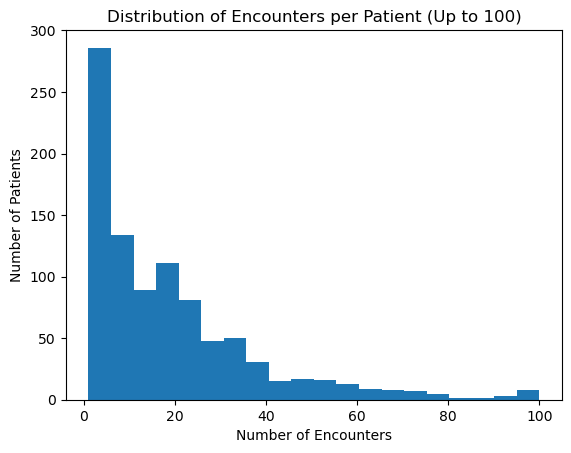

In [49]:
plt.hist(encounter_count[encounter_count <= 100], bins = 20)

plt.title('Distribution of Encounters per Patient (Up to 100)')
plt.xlabel('Number of Encounters')
plt.ylabel('Number of Patients')

plt.show()

### Age vs Number of Encounters

In [50]:
patient_encounters = encounter_count.rename('Number_of_Encounters')

age_encounters = df[['Id', 'Age']].merge(
    patient_encounters,
    left_on = 'Id',
    right_index = True,
    how = 'inner'
)

print(age_encounters.head())

                                     Id  Age  Number_of_Encounters
0  5605b66b-e92d-c16c-1b83-b8bf7040d51f   49                    18
1  6e5ae27c-8038-7988-e2c0-25a103f01bfa   86                     1
2  8123d076-0886-9007-e956-d5864aa121a7   68                     7
3  770518e4-6133-648e-60c9-071eb2f0e2ce   97                    27
4  f96addf5-81b9-0aab-7855-d208d3d352c5   97                     9


### Correlation Between Age and Encounters

In [51]:
correlation = age_encounters['Age'].corr(
    age_encounters['Number_of_Encounters']
)

print(correlation.round(2))

0.13


### Age vs Number of Encounters Scatter Plot

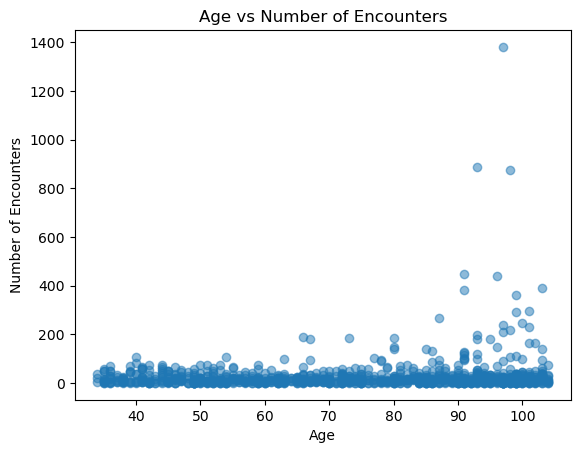

In [52]:
plt.scatter(
    age_encounters['Age'],
    age_encounters['Number_of_Encounters'],
    alpha = 0.5
)

plt.title('Age vs Number of Encounters')
plt.xlabel('Age')
plt.ylabel('Number of Encounters')

plt.show()

### Identify High-Utilization Outliers

In [53]:
Q1 = encounter_count.quantile(0.25)
Q3 = encounter_count.quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Outlier Limit:", upper_limit)

Q1: 4.0
Q3: 28.0
IQR: 24.0
Upper Outlier Limit: 64.0


### Count High-Utilization Patients

#### How many patients have more than 64 encounters?

In [54]:
high_utilization = encounter_count[encounter_count > upper_limit]

print("Number of high-utilization patients:", len(high_utilization))

Number of high-utilization patients: 75


### Encounters from High-Utilization Patients

In [55]:
high_utilization_encounters = high_utilization.sum()
total_encounters = encounter_count.sum()

percentage_of_encounters = (
    high_utilization_encounters / total_encounters
) * 100

print("Encounters by high-utilization patients:", high_utilization_encounters)
print("Total encounters:", total_encounters)
print("Percentage of all encounters:", round(percentage_of_encounters, 2))

Encounters by high-utilization patients: 13508
Total encounters: 27891
Percentage of all encounters: 48.43


### Calculate Total Claim Cost per Patient

In [56]:
patient_cost = (
    encounters.groupby('PATIENT')['TOTAL_CLAIM_COST']
    .sum()
    .sort_values(ascending = False)
)

print(patient_cost.head(10))

PATIENT
3f523789-55f3-bb31-2757-4803ca6a9c2a    9932262.99
ff331e5c-ab16-e218-f39a-63e11de1ed75    6356665.66
a733bbc1-cbdf-992f-f1b7-bd230028fc4f    3014121.02
2aa3ac2a-88c6-3253-547d-6d8ed69790a3    2699823.10
1712d26d-822d-1e3a-2267-0a9dba31d7c8    2437415.31
eda6bc14-b236-e8c6-509a-b293e9cc688b    2090033.12
37448778-ee2f-f420-1dc0-cb6b5e147025    1206558.16
fea2a30d-f7c9-eeb0-9aad-5c711f55574f    1181185.96
0226f105-2572-1c6f-15f0-1aa0438e40d0    1127635.83
1375a6a6-5638-8af1-dc4f-2aa58220d36d    1030983.91
Name: TOTAL_CLAIM_COST, dtype: float64


### Calculate Cost Share of High-Utilization Patients

#### What percentage of the hospital's total claim cost is generated by the 75 high-utilization patients?

In [57]:
high_utilization_cost = patient_cost[
    patient_cost.index.isin(high_utilization.index)
].sum()

total_cost = encounters['TOTAL_CLAIM_COST'].sum()

cost_percentage = (
    high_utilization_cost / total_cost
) * 100

print("Cost from high-utilization patients:", round(high_utilization_cost, 2))
print("Total claim cost:", round(total_cost, 2))
print("Percentage of total cost:", round(cost_percentage, 2))

Cost from high-utilization patients: 43868525.6
Total claim cost: 101514375.52
Percentage of total cost: 43.21


### Cost by Encounter Type

#### Which types of healthcare encounters contribute the most to total claim costs?

In [58]:
cost_by_encounter = (
    encounters.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST']
    .agg(['count', 'sum', 'mean'])
    .round(2)
    .sort_values('sum', ascending = False)
)

print(cost_by_encounter)

                count          sum     mean
ENCOUNTERCLASS                             
ambulatory      12537  36283440.84  2894.11
urgentcare       3666  23349349.96  6369.16
outpatient       6300  14094967.12  2237.30
emergency        2322  10750051.53  4629.65
inpatient        1135   8809134.34  7761.35
wellness         1931   8227431.73  4260.71


### Monthly Encounter Trend

#### How does the number of healthcare encounters change from month to month?

In [59]:
monthly_encounters = (
    encounters.assign(
        MONTH = pd.to_datetime(encounters['START']).dt.to_period('M')
    )
    .groupby('MONTH')
    .size()
)

print(monthly_encounters)

MONTH
2011-01     86
2011-02     86
2011-03    129
2011-04    113
2011-05    131
          ... 
2021-10    225
2021-11    267
2021-12    231
2022-01    219
2022-02      1
Freq: M, Length: 134, dtype: int64


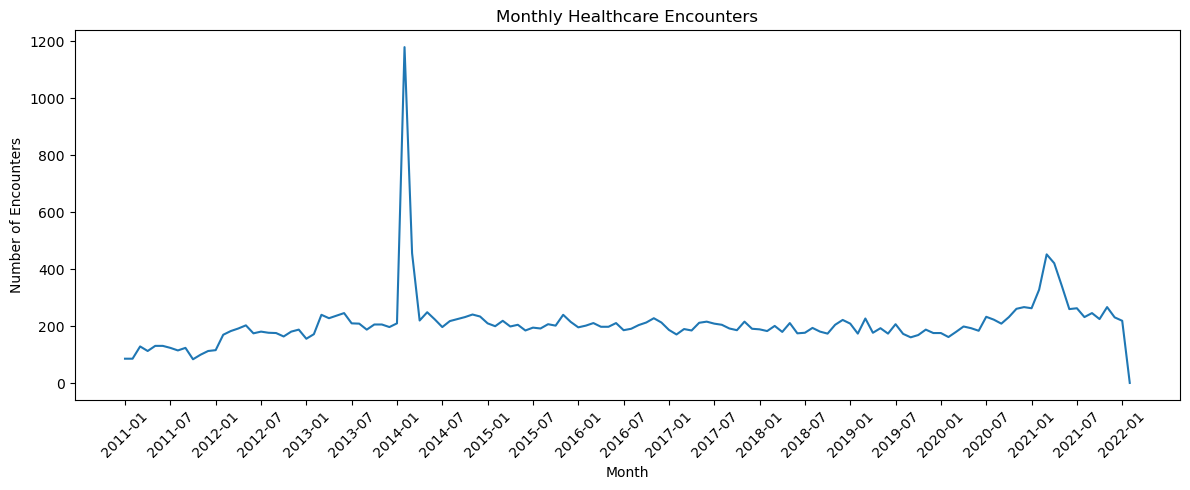

In [60]:
plt.figure(figsize = (12, 5))

plt.plot(
    monthly_encounters.index.astype(str),
    monthly_encounters.values
)

plt.title('Monthly Healthcare Encounters')
plt.xlabel('Month')
plt.ylabel('Number of Encounters')

plt.xticks(
    range(0, len(monthly_encounters), 6),
    monthly_encounters.index.astype(str)[::6],
    rotation = 45
)

plt.tight_layout()
plt.show()

### Top 10 Months by Encounter Volume

In [61]:
top_months = (
    monthly_encounters
    .sort_values(ascending = False)
    .head(10)
)

print(top_months)

MONTH
2014-02    1179
2014-03     456
2021-03     452
2021-04     421
2021-05     342
2021-02     328
2021-11     267
2020-12     267
2021-01     263
2021-07     263
Freq: M, dtype: int64


### Encounter Types During the Spike

#### Which encounter types caused the huge February 2014 spike?

In [62]:
feb_2014 = encounters[
    pd.to_datetime(encounters['START']).dt.to_period('M') == '2014-02'
]

spike_by_class = (
    feb_2014.groupby('ENCOUNTERCLASS')
    .size()
    .sort_values(ascending = False)
)

print(spike_by_class)

ENCOUNTERCLASS
ambulatory    930
outpatient    188
urgentcare     24
emergency      16
wellness       15
inpatient       6
dtype: int64


##### Let's inspect the descriptions/reasons for those 930 ambulatory encounters. That may reveal whether the spike came from a particular type of visit or service.

### Investigate Ambulatory Spike

In [63]:
ambulatory_feb_2014 = feb_2014[
    feb_2014['ENCOUNTERCLASS'] == 'ambulatory'
]

print(
    ambulatory_feb_2014['DESCRIPTION']
    .value_counts()
    .head(10)
)

DESCRIPTION
Patient encounter procedure (procedure)    850
Encounter for problem (procedure)           24
Telemedicine consultation with patient      16
Follow-up encounter                          9
Encounter for symptom                        7
Prenatal visit                               6
Prenatal initial visit                       5
Asthma follow-up                             4
Office Visit                                 2
Encounter for 'check-up'                     2
Name: count, dtype: int64


### Patients Behind the February 2014 Spike

In [64]:
spike_patients = (
    ambulatory_feb_2014
    .groupby('PATIENT')
    .size()
    .sort_values(ascending = False)
)

print(spike_patients.head(10))

PATIENT
c06513da-7f35-b4eb-5bab-28c87ff97a10    25
3de74169-7f67-9304-91d4-757e0f3a14d2    10
e3eeac06-7f9d-8e95-5cce-2dea6641f469    10
1712d26d-822d-1e3a-2267-0a9dba31d7c8    10
92390d09-7f82-3be6-c334-c4ecf6b5b0d1     9
227aed94-d7ed-200d-2c52-e51ed58156c4     9
a31f5105-476f-b129-fb9a-514cf45a34ac     9
53a74f22-fdb4-ae9a-6ac4-79bad2126039     9
2bbe538c-3a52-93d7-f68a-af7d2560e1a5     9
9b6a7d3e-3cf2-3c4a-029e-bc7f3d15ca20     9
dtype: int64


### Distribution of Spike Across Patients

In [65]:
print("Unique patients:", spike_patients.count())
print("Average encounters per patient:", round(spike_patients.mean(), 2))
print("Maximum encounters for one patients:", spike_patients.max())

Unique patients: 143
Average encounters per patient: 6.5
Maximum encounters for one patients: 25


### Monthly Healthcare Spending

#### Does healthcare spending follow the same pattern as encounter volume?

In [66]:
monthly_cost = (
    encounters.assign(
        MONTH = pd.to_datetime(encounters['START']).dt.to_period('M')
    )
    .groupby('MONTH')['TOTAL_CLAIM_COST']
    .sum()
)

print(monthly_cost)

MONTH
2011-01     259121.74
2011-02     305801.38
2011-03     327225.51
2011-04     386556.64
2011-05     417517.16
              ...    
2021-10    1029468.43
2021-11     828955.78
2021-12     796630.24
2022-01     691474.06
2022-02          0.00
Freq: M, Name: TOTAL_CLAIM_COST, Length: 134, dtype: float64


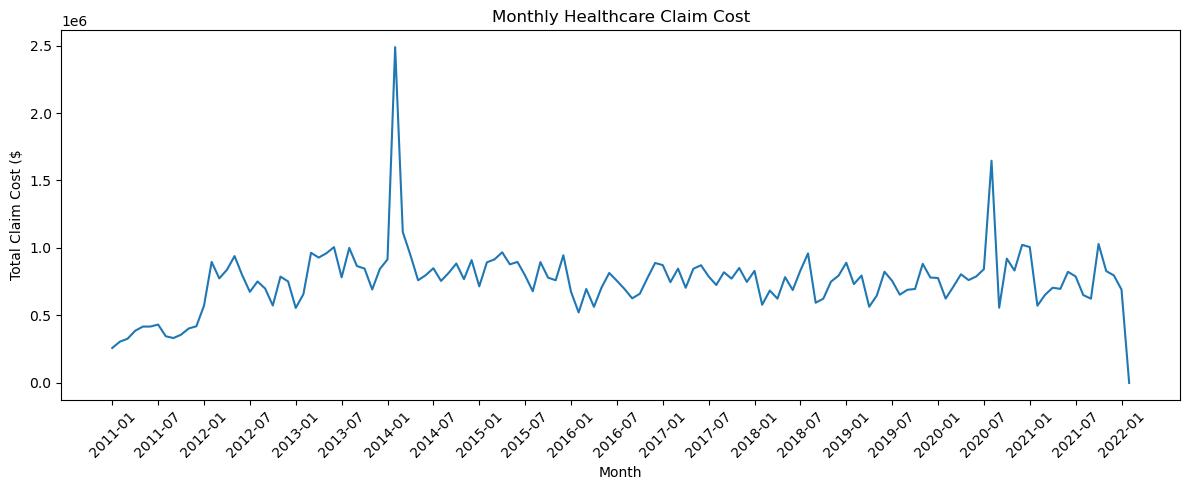

In [67]:
plt.figure(figsize = (12, 5))

plt.plot(
    monthly_cost.index.astype(str),
    monthly_cost.values
)

plt.title("Monthly Healthcare Claim Cost")
plt.xlabel('Month')
plt.ylabel('Total Claim Cost ($')

plt.xticks(
    range(0, len(monthly_cost), 6),
    monthly_cost.index.astype(str)[::6],
    rotation = 45
)

plt.tight_layout()
plt.show()

### Top 10 Months by Healthcare Cost

In [68]:
top_cost_months = (
    monthly_cost
    .sort_values(ascending = False)
    .head(10)
)

print(top_cost_months)

MONTH
2014-02    2488151.91
2020-08    1646407.05
2014-03    1117733.43
2021-10    1029468.43
2020-12    1022942.49
2021-01    1006919.14
2013-06    1006208.88
2013-08    1000342.89
2015-04     967845.18
2013-03     964026.08
Freq: M, Name: TOTAL_CLAIM_COST, dtype: float64


### Cost and Volume of Top Expensive Months

In [69]:
top_month_analysis = pd.DataFrame({
    'Total_Cost' : monthly_cost.loc[top_cost_months.index],
    'Number_of_Encounters': monthly_encounters.loc[top_cost_months.index]
})

top_month_analysis['Average_Cost_Per_Encounter'] = (
    top_month_analysis['Total_Cost'] /
    top_month_analysis['Number_of_Encounters']
).round(2)

print(top_month_analysis)

         Total_Cost  Number_of_Encounters  Average_Cost_Per_Encounter
MONTH                                                                
2014-02  2488151.91                  1179                     2110.39
2020-08  1646407.05                   223                     7382.99
2014-03  1117733.43                   456                     2451.17
2021-10  1029468.43                   225                     4575.42
2020-12  1022942.49                   267                     3831.25
2021-01  1006919.14                   263                     3828.59
2013-06  1006208.88                   246                     4090.28
2013-08  1000342.89                   209                     4786.33
2015-04   967845.18                   199                     4863.54
2013-03   964026.08                   240                     4016.78


#### August 2020 has the highest average cost per encounter among these top-cost months.

### August 2020 Cost by Encounter Type

In [70]:
aug_2020 = encounters[
    pd.to_datetime(encounters['START']).dt.to_period('M') == '2020-08'
]

aug_2020_analysis = (
    aug_2020.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST']
    .agg(['count', 'sum', 'mean'])
    .round(2)
    .sort_values('sum', ascending = False)
)

print(aug_2020_analysis)

                count        sum      mean
ENCOUNTERCLASS                            
emergency          18  730693.79  40594.10
inpatient           8  350036.35  43754.54
urgentcare         31  219327.27   7075.07
outpatient         48  172157.06   3586.61
ambulatory        106  134051.30   1264.63
wellness           12   40141.28   3345.11


### Most Expensive Encounters in August 2020

In [71]:
top_aug_2020 = (
    aug_2020[
        ['PATIENT', 'ENCOUNTERCLASS', 'DESCRIPTION', 'TOTAL_CLAIM_COST']
    ]
    .sort_values('TOTAL_CLAIM_COST', ascending = False)
    .head(10)
)

print(top_aug_2020.to_string(index = False))

                             PATIENT ENCOUNTERCLASS                                  DESCRIPTION  TOTAL_CLAIM_COST
01296e88-f6d9-1c18-cf91-87523325e034      emergency                        Encounter for problem         641882.70
1ed4864d-27c6-0205-9cb9-b8883686ab89      inpatient Admission to intensive care unit (procedure)         309748.16
3f523789-55f3-bb31-2757-4803ca6a9c2a      emergency                          Emergency Encounter          40071.66
5427845a-82ab-b6c9-e70b-aeb672ddd5d7     urgentcare               Urgent care clinic (procedure)          33414.65
8a72615e-cd5a-c700-7bdc-7608cb4280dc     outpatient           Encounter for check up (procedure)          29911.10
74f91c28-2811-67b8-8828-201f0e125dd5     urgentcare               Urgent care clinic (procedure)          27312.25
f3979e92-6b6c-67a0-aed9-6e07072cfaa6       wellness   General examination of patient (procedure)          26430.15
1712d26d-822d-1e3a-2267-0a9dba31d7c8     outpatient           Encounter for chec

In [72]:
procedures = pd.read_csv("procedures.csv")

In [73]:
procedures

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,REASONCODE,REASONDESCRIPTION
0,2011-01-02T09:26:36Z,2011-01-02T12:58:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,NaN,NaN
1,2011-01-03T05:44:39Z,2011-01-03T06:01:42Z,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,NaN,NaN
2,2011-01-04T14:49:55Z,2011-01-04T15:04:55Z,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,363406005.0,Malignant tumor of colon
3,2011-01-05T04:02:09Z,2011-01-05T04:17:09Z,bc9d59c3-0a30-6e3b-f47d-022e4f03c8de,17966936-0878-f4db-128b-a43ae10d0878,173160006,Diagnostic fiberoptic bronchoscopy (procedure),9796,162573006.0,Suspected lung cancer (situation)
4,2011-01-05T12:58:36Z,2011-01-05T16:42:36Z,3de74169-7f67-9304-91d4-757e0f3a14d2,9de5f0b0-4ba4-ce6f-45fb-b55c202f31a5,265764009,Renal dialysis (procedure),1255,NaN,NaN
...,...,...,...,...,...,...,...,...,...
47696,2022-01-29T20:35:37Z,2022-01-29T20:50:37Z,ff1b3c26-53a6-4590-ce79-a3f7269274ea,01b57f06-cebe-a3e4-4423-a796ffb0c35d,430193006,Medication Reconciliation (procedure),413,NaN,NaN
47697,2022-01-29T20:35:37Z,2022-01-29T20:50:37Z,ff1b3c26-53a6-4590-ce79-a3f7269274ea,01b57f06-cebe-a3e4-4423-a796ffb0c35d,274804006,Evaluation of uterine fundal height,3238,72892002.0,Normal pregnancy
47698,2022-01-29T20:35:37Z,2022-01-29T20:50:37Z,ff1b3c26-53a6-4590-ce79-a3f7269274ea,01b57f06-cebe-a3e4-4423-a796ffb0c35d,225158009,Auscultation of the fetal heart,7045,72892002.0,Normal pregnancy
47699,2022-01-29T20:35:37Z,2022-01-29T20:50:37Z,ff1b3c26-53a6-4590-ce79-a3f7269274ea,01b57f06-cebe-a3e4-4423-a796ffb0c35d,118001005,Streptococcus pneumoniae group B antigen test,1559,72892002.0,Normal pregnancy


In [74]:
procedures.shape

(47701, 9)

### Most Frequently Performed Procedures

In [75]:
procedure_counts = (
    procedures['DESCRIPTION']
    .value_counts()
    .head(10)
)

print(procedure_counts)

DESCRIPTION
Assessment of health and social care needs (procedure)                                4596
Hospice care (regime/therapy)                                                         4098
Depression screening using Patient Health Questionnaire Two-Item score (procedure)    3614
Depression screening (procedure)                                                      3614
Assessment of substance use (procedure)                                               2906
Renal dialysis (procedure)                                                            2746
Assessment using Morse Fall Scale (procedure)                                         2422
Assessment of anxiety (procedure)                                                     2288
Medication Reconciliation (procedure)                                                 2284
Screening for drug abuse (procedure)                                                  1484
Name: count, dtype: int64


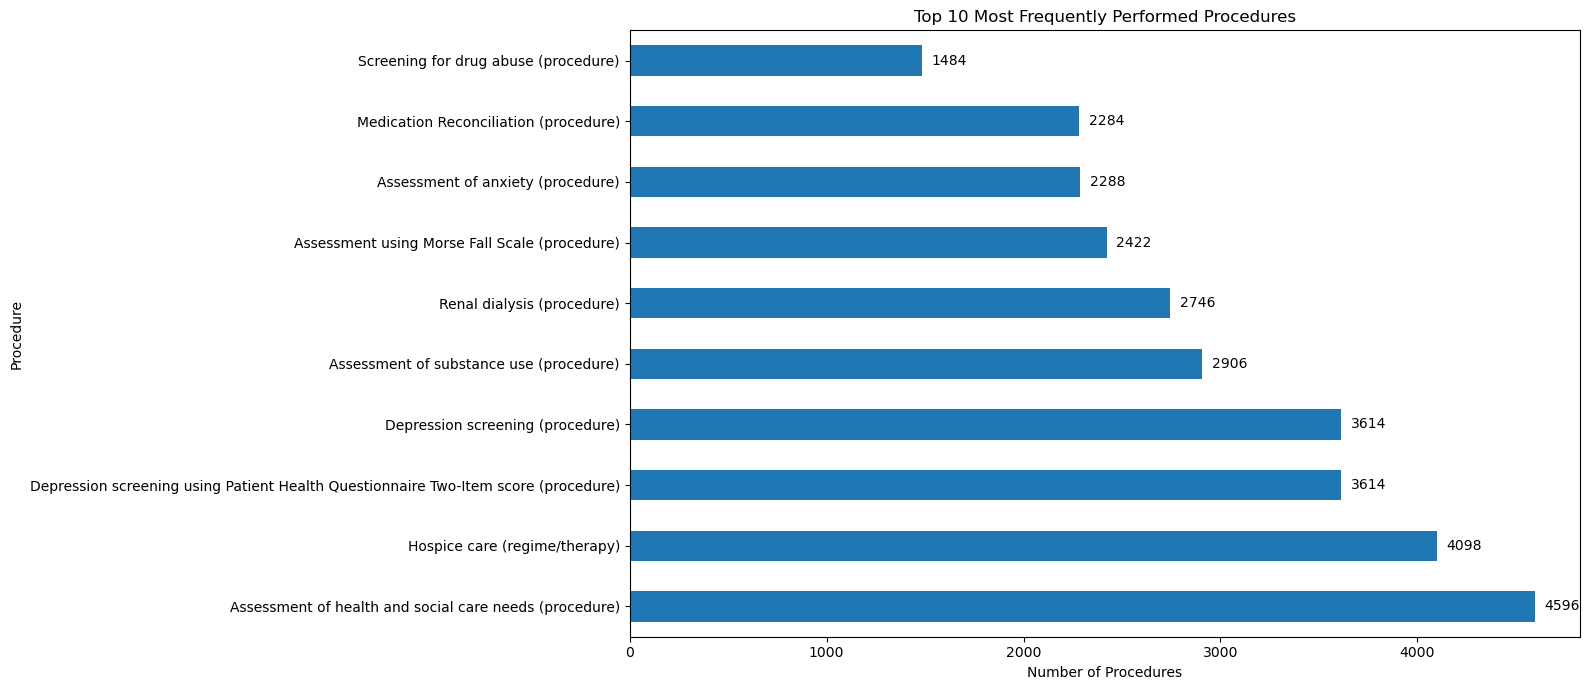

In [76]:
plt.figure(figsize = (16,7))

ax = procedure_counts.plot(kind = 'barh')

plt.title('Top 10 Most Frequently Performed Procedures')
plt.xlabel('Number of Procedures')
plt.ylabel('Procedure')

for i, value in enumerate(procedure_counts):
    ax.text(value + 50, i, str(value), va = 'center')

plt.tight_layout()
plt.show()

### Procedure Cost Data Type

In [77]:
procedures['BASE_COST'].dtype

dtype('int64')

### Top 10 Procedures by Total Cost

In [78]:
procedure_cost = (
    procedures.groupby('DESCRIPTION')['BASE_COST']
    .agg(['count', 'sum', 'mean'])
    .round(2)
    .sort_values('sum', ascending = False)
    .head(10)
)

print(procedure_cost)

                                                    count       sum      mean
DESCRIPTION                                                                  
Electrical cardioversion                             1383  35824002  25903.11
Auscultation of the fetal heart                      1065   5657822   5312.51
Evaluation of uterine fundal height                  1065   5631281   5287.59
Combined chemotherapy and radiation therapy (pr...    444   5237596  11796.39
Colonoscopy                                           424   5021003  11841.99
Catheter ablation of tissue of heart                  365   3405999   9331.50
Renal dialysis (procedure)                           2746   2757221   1004.09
Assessment of health and social care needs (pro...   4596   1980876    431.00
Bone density scan (procedure)                         198   1901367   9602.86
Hospice care (regime/therapy)                        4098   1766238    431.00


### Top 10 Procedures by Average Cost

In [79]:
procedure_avg_cost = (
    procedures.groupby('DESCRIPTION')['BASE_COST']
    .agg(['count', 'mean'])
    .round(2)
    .sort_values('mean', ascending = False)
    .head(10)
)

print(procedure_avg_cost)

                                                    count       mean
DESCRIPTION                                                         
Admit to ICU (procedure)                                5  206260.40
Coronary artery bypass grafting                         9   47085.89
Lumpectomy of breast (procedure)                        5   29353.00
Hemodialysis (procedure)                               27   29299.56
Insertion of biventricular implantable cardiove...      4   27201.00
Electrical cardioversion                             1383   25903.11
Partial resection of colon                              7   25229.29
Fine needle aspiration biopsy of lung (procedure)       1   23141.00
Percutaneous mechanical thrombectomy of portal ...     57   20228.04
Percutaneous coronary intervention                      9   19728.00


### Top 10 Procedures by Average Cost Chart

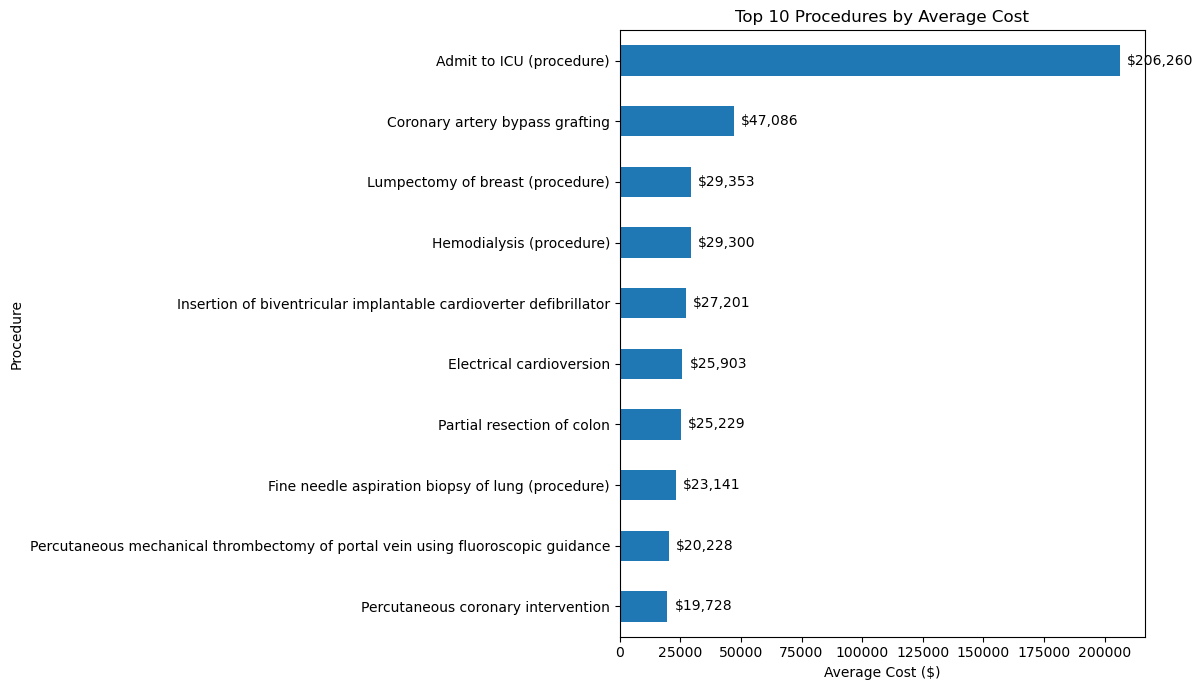

In [80]:
procedure_avg_cost = (
    procedures.groupby('DESCRIPTION')['BASE_COST']
    .mean()
    .sort_values(ascending = True)
    .tail(10)
)

plt.figure(figsize = (12,7))

ax = procedure_avg_cost.plot(kind = 'barh')

plt.title('Top 10 Procedures by Average Cost')
plt.xlabel('Average Cost ($)')
plt.ylabel('Procedure')

for i, value in enumerate(procedure_avg_cost):
    ax.text(float(value) + 3000, i, f'${value:,.0f}', va = 'center')

plt.tight_layout()
plt.show()

### Procedure Frequency vs Total Cost

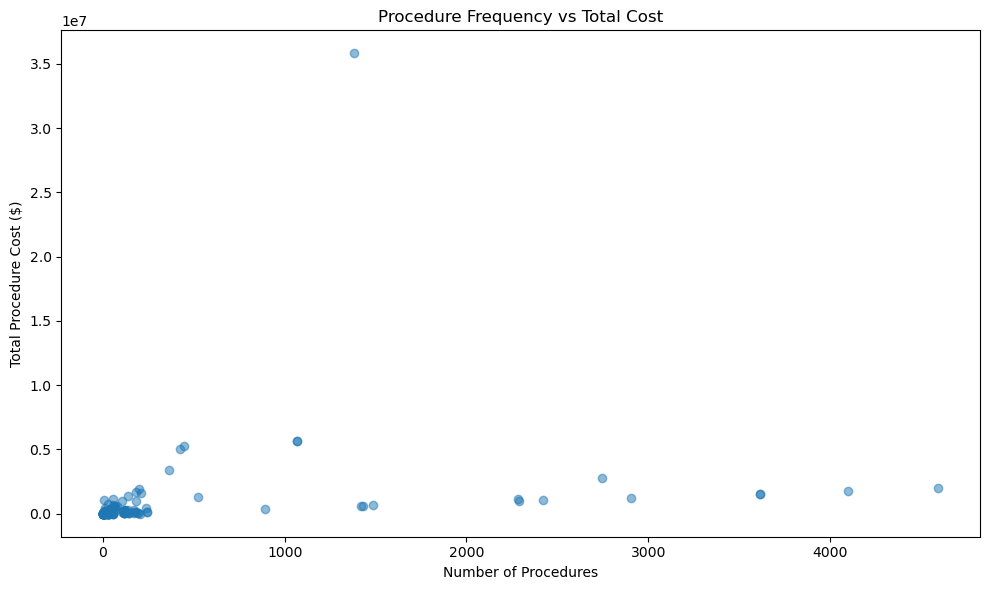

In [81]:
procedure_analysis = (
    procedures.groupby('DESCRIPTION')['BASE_COST']
    .agg(
        Number_of_Procedures = 'count',
        Total_Cost = 'sum'
    )
)

plt.figure(figsize = (10, 6))

plt.scatter(
    procedure_analysis['Number_of_Procedures'],
    procedure_analysis['Total_Cost'],
    alpha = 0.5
)

plt.title('Procedure Frequency vs Total Cost')
plt.xlabel('Number of Procedures')
plt.ylabel('Total Procedure Cost ($)')

plt.tight_layout()
plt.show()

### Zoomed Procedure Frequency vs Total Cost

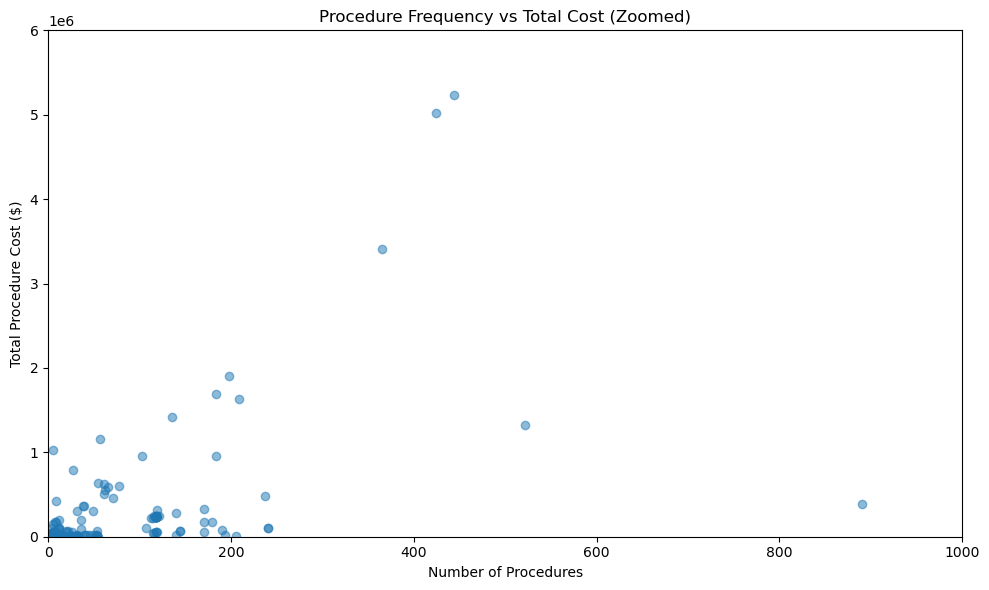

In [82]:
plt.figure(figsize = (10, 6))

plt.scatter(
    procedure_analysis['Number_of_Procedures'],
    procedure_analysis['Total_Cost'],
    alpha = 0.5
)

plt.xlim(0, 1000)
plt.ylim(0, 6000000)

plt.title('Procedure Frequency vs Total Cost (Zoomed)')
plt.xlabel('Number of Procedures')
plt.ylabel('Total Procedure Cost ($)')

plt.tight_layout()
plt.show()

### Top 10 Patients by Number of Procedures

In [83]:
patient_procedure_count = (
    procedures.groupby('PATIENT')
    .size()
    .sort_values(ascending = False)
    .head(10)
)

print(patient_procedure_count)

PATIENT
1712d26d-822d-1e3a-2267-0a9dba31d7c8    1783
5e055638-0dad-dfd5-005d-1e74b6fd29ac    1243
3de74169-7f67-9304-91d4-757e0f3a14d2    1170
ff331e5c-ab16-e218-f39a-63e11de1ed75     828
3f523789-55f3-bb31-2757-4803ca6a9c2a     759
1375a6a6-5638-8af1-dc4f-2aa58220d36d     602
b4ab9ab3-f52a-751e-a990-3bd5654d5870     540
0226f105-2572-1c6f-15f0-1aa0438e40d0     526
3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b     498
36412d54-5a49-0dc6-5bab-3749c92f79d9     497
dtype: int64


### Encounters vs Procedures per Patient

In [84]:
patient_encounter_count = encounters.groupby('PATIENT').size()
patient_procedure_count = procedures.groupby('PATIENT').size()
patient_utilization = pd.DataFrame({
    'Number_of_Encounters': patient_encounter_count,
    'Number_of_Procedures': patient_procedure_count
}).fillna(0)

correlation = patient_utilization[
    ['Number_of_Encounters', 'Number_of_Procedures']
].corr().iloc[0, 1]

print("Correlation:", round(correlation, 2))

Correlation: 0.86


#### A strong positive correlation (r = 0.86) was observed between patient encounter frequency and procedure frequency, indicating that patients with higher healthcare utilization tend to have substantially more recorded procedures.

In [85]:
print(df[['BIRTHDATE', 'Age', 'Age_Group']].head())

   BIRTHDATE  Age Age_Group
0 1977-03-19   49     41-60
1 1940-02-19   86    81-100
2 1958-06-04   68     61-80
3 1928-12-25   97    81-100
4 1928-12-25   97    81-100


In [86]:
df.to_csv("patients_analysis.csv", index=False)

### Payer Coverage Analysis

In [87]:
payer_analysis = (
    encounters.groupby('PAYER')
    .agg(
        Total_Claim_Cost = ('TOTAL_CLAIM_COST', 'sum'),
        Total_Payer_Coverage = ('PAYER_COVERAGE', 'sum'),
        Number_of_Encounters = ('PAYER', 'count')
    )
    .reset_index()
)

payer_analysis['Payer_Coverage_Percentage'] = ( 
    payer_analysis['Total_Payer_Coverage'] /payer_analysis['Total_Claim_Cost'] * 100
).round(2)

payer_analysis

,PAYER,Total_Claim_Cost,Total_Payer_Coverage,Number_of_Encounters,Payer_Coverage_Percentage
0,047f6ec3-6215-35eb-9608-f9dda363a44c,2424532.96,968.35,809,0.04
1,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,2982715.05,0.00,704,0.00
2,4d71f845-a6a9-3c39-b242-14d25ef86a8d,2589956.10,1780.16,936,0.07
3,5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,2563507.98,3937.32,900,0.15
4,6e2f1a2d-27bd-3701-8d08-dae202c58632,3002166.01,2074496.34,925,69.10
5,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,8954131.02,8417973.72,1443,94.01
6,7caa7254-5050-3b5e-9eae-bd5ea30e809c,24647228.89,19215691.37,11371,77.96
7,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,49259290.16,0.00,8807,0.00
8,b3221cfc-24fb-339e-823d-bc4136cbc4ed,1546925.99,1380705.87,912,89.25
9,d47b3510-2895-3b70-9897-342d681c769d,3543921.36,1953.86,1084,0.06


In [88]:
payer_analysis.to_csv("payer_analysis.csv", index=False)

In [89]:
import os

print(os.path.exists("payer_analysis.csv"))

True


### Procedure Frequency and Cost Analysis

In [90]:
procedure_analysis = (
    procedures.groupby('DESCRIPTION')['BASE_COST']
    .agg(
        Number_of_Procedures = 'count',
        Total_Cost = 'sum'
    )
    .reset_index()
)

print(procedure_analysis.head())

                              DESCRIPTION  Number_of_Procedures  Total_Cost
0                  Admission to burn unit                     1         431
1         Admission to long stay hospital                     1         431
2      Admission to orthopedic department                    42       18102
3  Admission to trauma surgery department                     3        1293
4                Admit to ICU (procedure)                     5     1031302


In [91]:
procedure_analysis.to_csv("procedure_analysis.csv", index = False)

In [92]:
print(os.path.exists("procedure_analysis.csv"))

True


### Top 10 Patients by Number of Encounters

In [93]:
top_patient_encounters = (
    encounters.groupby('PATIENT')
    .size()
    .reset_index(name = 'Number_of_Encounters')
    .sort_values('Number_of_Encounters', ascending = False)
    .head(10)
)

print(top_patient_encounters)

                                  PATIENT  Number_of_Encounters
85   1712d26d-822d-1e3a-2267-0a9dba31d7c8                  1381
371  5e055638-0dad-dfd5-005d-1e74b6fd29ac                   887
240  3de74169-7f67-9304-91d4-757e0f3a14d2                   877
245  3f523789-55f3-bb31-2757-4803ca6a9c2a                   447
370  5dcb295d-92df-a147-ebcc-aa49b6262830                   441
275  442dc617-c7f2-0513-15cd-c35c4efdba73                   392
694  b4ab9ab3-f52a-751e-a990-3bd5654d5870                   383
600  9b8ae606-5059-b3a6-19c7-c812901898bb                   364
693  b4671e80-7e87-9260-ca31-6a9397d465d1                   296
973  ff331e5c-ab16-e218-f39a-63e11de1ed75                   291


##### Export Top Patient Encounters

In [94]:
top_patient_encounters.to_csv("top_patient_encounters.csv", index = False)

##### Check Top Patient Encounters File

In [95]:
print(os.path.exists("top_patient_encounters.csv"))

True


### High Utilization Patient Analysis

In [96]:
high_utilization = encounter_count[encounter_count > upper_limit]

high_utilization_patient_count = len(high_utilization)
other_patient_count = len(encounter_count) - high_utilization_patient_count

high_utilization_encounters = high_utilization.sum()
other_encounters = encounter_count.sum() - high_utilization_encounters

high_utilization_cost = patient_cost[
    patient_cost.index.isin(high_utilization.index)
].sum()

other_cost = total_cost - high_utilization_cost

high_utilization_analysis = pd.DataFrame({
    'Patient_Group': [
        'High Utilization',
        'Other Patients'
    ],
    'Number_of_Patients': [
        high_utilization_patient_count,
        other_patient_count
    ],
    'Number_of_Encounters': [
        high_utilization_encounters,
        other_encounters
    ],
    'Total_Claim_Cost': [
        high_utilization_cost,
        other_cost
    ]
})

high_utilization_analysis

,Patient_Group,Number_of_Patients,Number_of_Encounters,Total_Claim_Cost
0,High Utilization,75,13508,43868525.60
1,Other Patients,899,14383,57645849.92


##### Export High Utilization Analysis

In [97]:
high_utilization_analysis.to_csv(
    "high_utilization_analysis.csv",
    index = False
)

In [98]:
print(os.path.exists("high_utilization_analysis.csv"))

True


In [99]:
age_order = {
    '34-40': 1,
    '41-60': 2,
    '61-80': 3,
    '81-100': 4,
    '101+': 5
}

df['Age_Group_Sort'] = df['Age_Group'].map(age_order)

In [100]:
df.to_csv("patients_analysis.csv", index = False)

### modify existing top_patient_encounters

In [101]:
top_patient_encounters = (
    encounters.groupby('PATIENT')
    .size()
    .reset_index(name='Number_of_Encounters')
    .sort_values('Number_of_Encounters', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_patient_encounters['Patient_Label'] = (
    'Patient ' + (top_patient_encounters.index + 1).astype(str)
)

In [102]:
top_patient_encounters.to_csv(
    "top_patient_encounters.csv",
    index=False
)